# EfficientNet training
This notebook trains an EfficientNet model for multi-class classification on the ERCP dataset.

In [1]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config
from monai.transforms import RandGaussianSmooth

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

import torch
from torch.utils.data import Dataset
#from torchvision.models import efficientnet_b7
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

from collections import Counter
from torch.utils.data import WeightedRandomSampler



np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 2.4.0
Pytorch version: 2.10.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: C:\Users\<username>\AppData\Roaming\Python\Python314\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.16.3
Pillow version: 12.0.0
Tensorboard version: 2.20.0
gdown version: 6.0.0
TorchVision version: 0.25.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.1.3
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: 4.57.3
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN 

In [ ]:
model_name = './models/efficientnet_rr_13.pth'

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Aplicar CLAHE:

uma única vez,
guardar imagens processadas,
treinar depois diretamente sobre elas.

Isto:

acelera MUITO o treino,
evita CPU bottleneck,
torna o pipeline reproduzível,


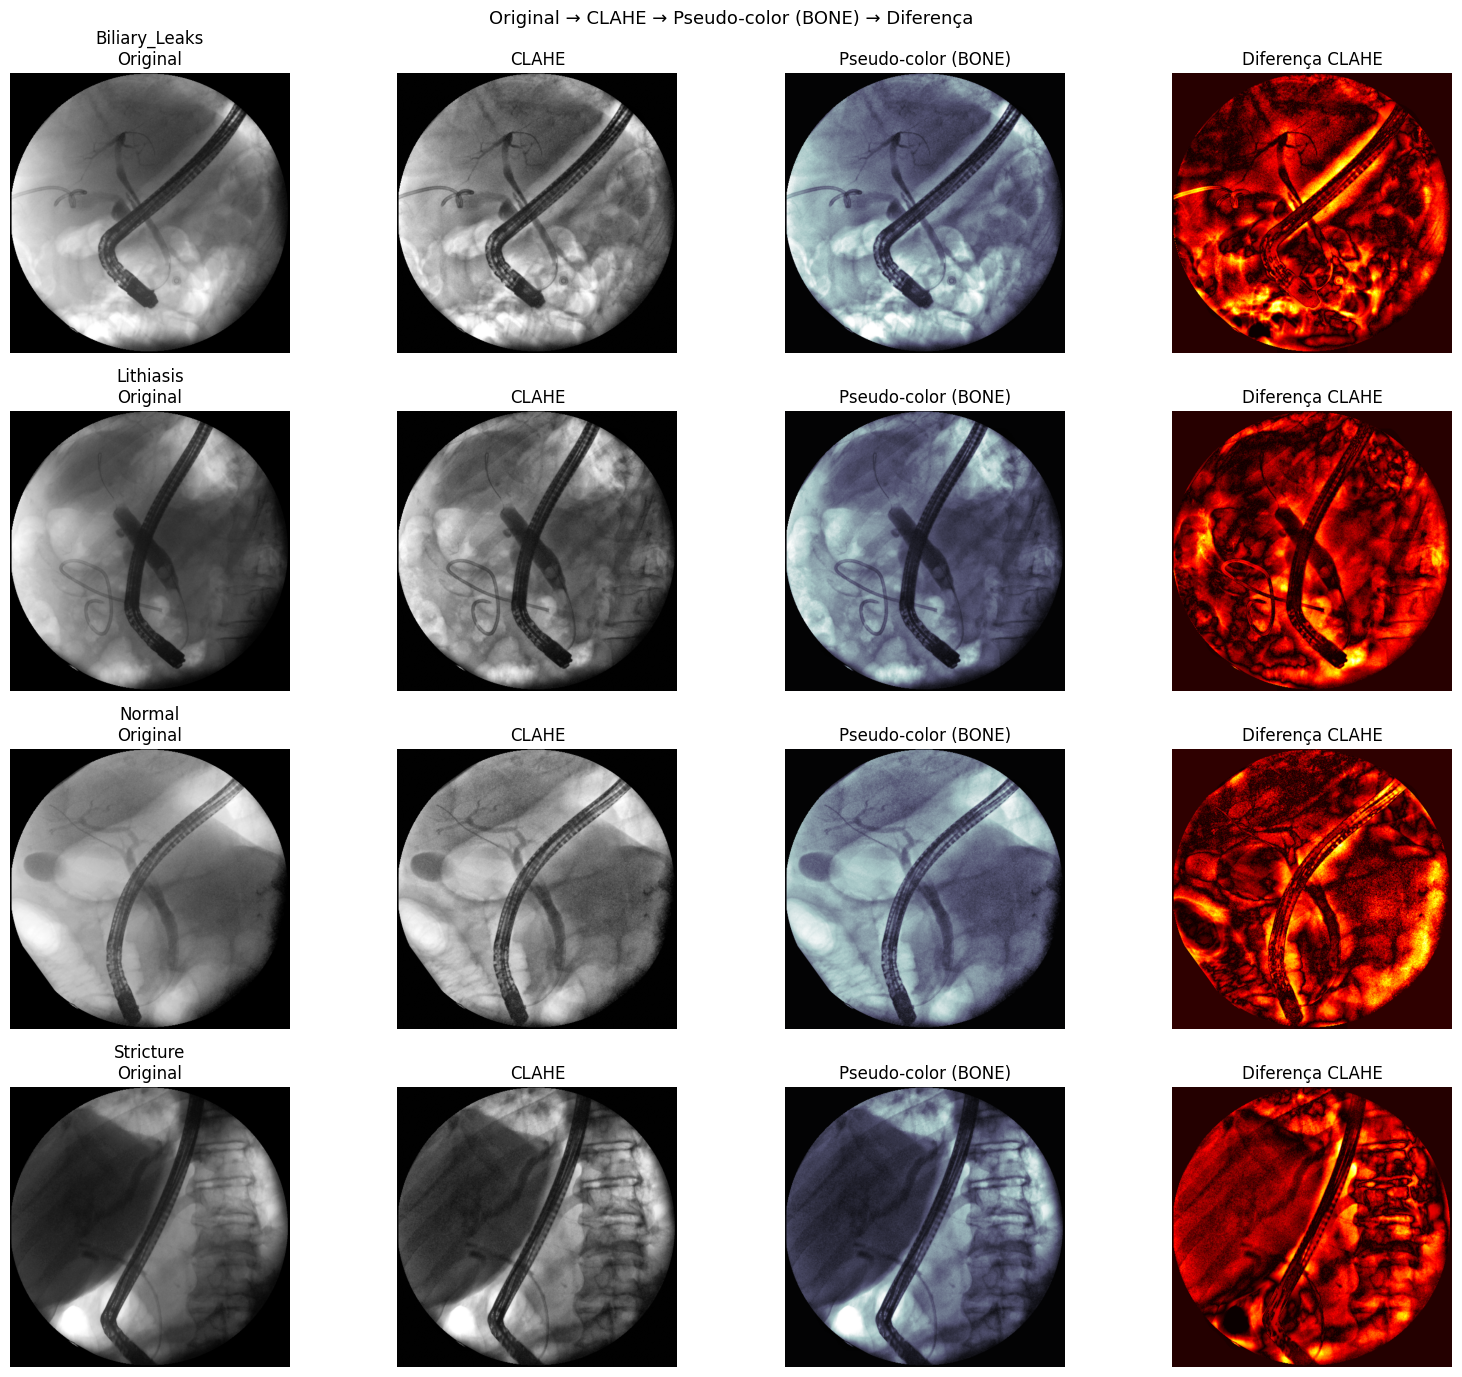

Saved: clahe_color_comparison.png
  train/Biliary_Leaks: 110 images


  train/Lithiasis: 505 images


  train/Normal: 197 images


  train/Stricture: 255 images


  val/Biliary_Leaks: 24 images


...

  test/Biliary_Leaks: 17 images


  test/Lithiasis: 123 images


  test/Normal: 43 images


  test/Stricture: 84 images



Done. 0 images → dataset_clahe_color/
Next: update base_dir to dataset_clahe_color in the data loading cell


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

INPUT_DIR  = "dataset"
OUTPUT_DIR = "dataset_clahe_color"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLIP_LIMIT = 2.0
TILE_GRID  = (16, 16)

def process_image(img_gray):
    """
    Pipeline:
    1. CLAHE no canal de luminância
    2. Pseudo-color via COLORMAP_BONE — mantém aparência radiológica
       mas dá ao EfficientNet 3 canais distintos em vez de 3 canais iguais
    """
    clahe = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=TILE_GRID)
    img_clahe = clahe.apply(img_gray)
    # COLORMAP_BONE: azul-acinzentado, próximo do look radiológico
    # Alternativas: COLORMAP_HOT, COLORMAP_INFERNO
    img_color = cv2.applyColorMap(img_clahe, cv2.COLORMAP_BONE)
    return img_color   # BGR, 3 canais distintos

# ── Visualização comparativa ──────────────────────────────────────────────────
def show_comparison(input_dir, n_per_class=1):
    classes = sorted([c for c in os.listdir(input_dir)
                      if os.path.isdir(os.path.join(input_dir, c))])
    fig, axes = plt.subplots(len(classes), 4,
                             figsize=(16, 3.5 * len(classes)))
    fig.suptitle("Original → CLAHE → Pseudo-color (BONE) → Diferença", fontsize=13)

    for row, cls in enumerate(classes):
        cls_dir = os.path.join(input_dir, cls)
        imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if not imgs:
            continue

        img_path = os.path.join(cls_dir, imgs[0])
        img_raw  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        clahe_op = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=TILE_GRID)
        img_cl   = clahe_op.apply(img_raw)
        img_col  = cv2.applyColorMap(img_cl, cv2.COLORMAP_BONE)
        img_col_rgb = cv2.cvtColor(img_col, cv2.COLOR_BGR2RGB)
        diff     = cv2.absdiff(img_raw, img_cl)

        axes[row, 0].imshow(img_raw,     cmap="gray");  axes[row, 0].set_title(f"{cls}\nOriginal");     axes[row, 0].axis("off")
        axes[row, 1].imshow(img_cl,      cmap="gray");  axes[row, 1].set_title("CLAHE");                 axes[row, 1].axis("off")
        axes[row, 2].imshow(img_col_rgb);               axes[row, 2].set_title("Pseudo-color (BONE)");   axes[row, 2].axis("off")
        axes[row, 3].imshow(diff,        cmap="hot");   axes[row, 3].set_title("Diferença CLAHE");       axes[row, 3].axis("off")

    plt.tight_layout()
    plt.savefig("clahe_color_comparison.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: clahe_color_comparison.png")

train_dir = os.path.join(INPUT_DIR, "train")
if os.path.exists(train_dir):
    show_comparison(train_dir)
else:
    print(f"Dataset not found at {INPUT_DIR} — skipping visual")

# ── Processar dataset ─────────────────────────────────────────────────────────
splits = ["train", "val", "test"]
total  = 0

for split in splits:
    split_input  = os.path.join(INPUT_DIR,  split)
    split_output = os.path.join(OUTPUT_DIR, split)
    os.makedirs(split_output, exist_ok=True)

    if not os.path.exists(split_input):
        print(f"Skipping {split} — not found"); continue

    for cls in os.listdir(split_input):
        in_dir  = os.path.join(split_input,  cls)
        out_dir = os.path.join(split_output, cls)
        if not os.path.isdir(in_dir): continue
        os.makedirs(out_dir, exist_ok=True)

        files = [f for f in os.listdir(in_dir)
                 if f.lower().endswith(('.png','.jpg','.jpeg'))]
        print(f"  {split}/{cls}: {len(files)} images")

        for fname in tqdm(files, desc=f"{split}/{cls}", leave=False):
            out_path = os.path.join(out_dir, fname)
            if os.path.exists(out_path): continue

            img = cv2.imread(os.path.join(in_dir, fname), cv2.IMREAD_GRAYSCALE)
            if img is None: continue

            img_processed = process_image(img)
            cv2.imwrite(out_path, img_processed)
            total += 1

print(f"\nDone. {total} images → {OUTPUT_DIR}/")
print("Next: update base_dir to dataset_clahe_color in the data loading cell")


## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [5]:
#base_dir = './dataset'  # raw images — NOT used
base_dir = './dataset_clahe_color'  # CLAHE + pseudo-color  # CLAHE-preprocessed — USE THIS
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


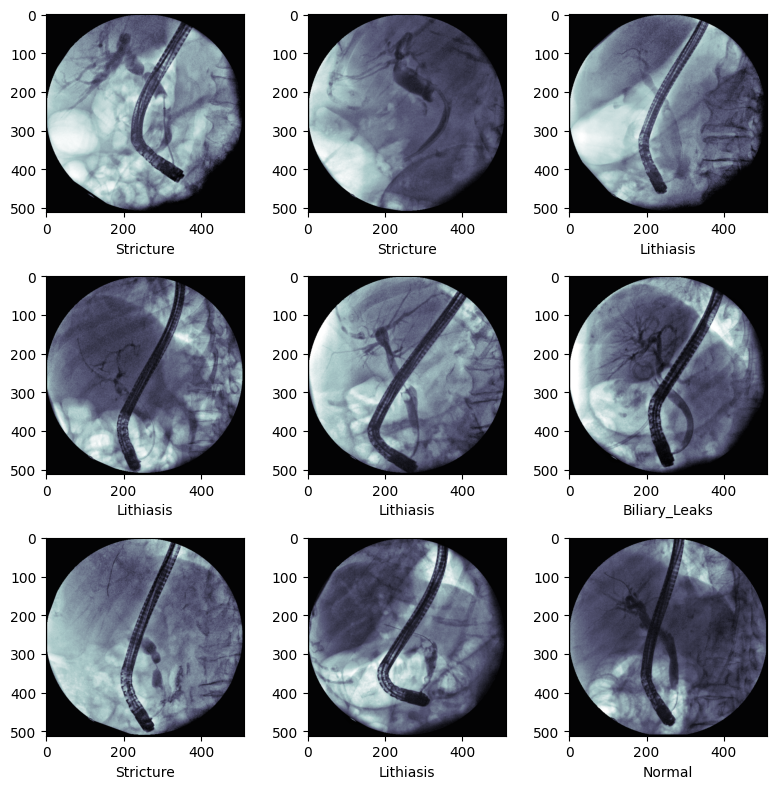

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


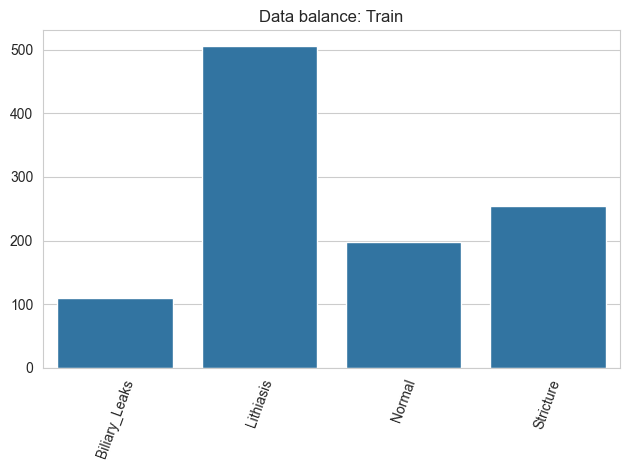

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


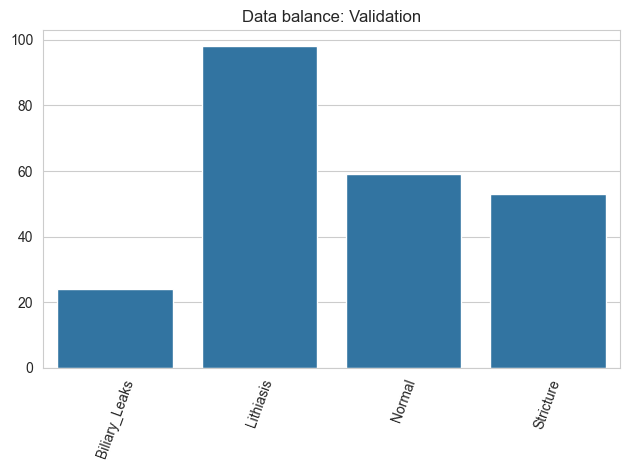

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


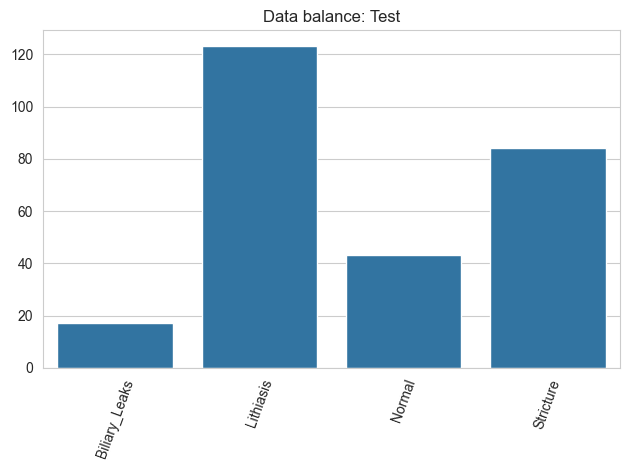

In [7]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 512×512.

In [8]:
# class EnsureSingleChannel:
#     def __call__(self, img):
#         if img.shape[0] == 3:
#             img = img.mean(dim=0, keepdim=True)
#         return img

# def repeat_if_needed(img):
#     if img.shape[0] == 1:
#         return img.repeat(3, 1, 1)
#     return img
    
# train_transforms = Compose([
#     LoadImage(image_only=True),
#     EnsureChannelFirst(),
#     Resize((512, 512)),
#     RandRotate(range_x=15, prob=0.5),
#     RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
#     RandAdjustContrast(prob=0.5),
#     RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
#     NormalizeIntensity(),
#     Lambda(repeat_if_needed),
#     ToTensor()
# ])

# val_transforms = Compose([
#     LoadImage(image_only=True),
#     EnsureChannelFirst(),
#     Resize((512, 512)),
#     NormalizeIntensity(),
#     Lambda(repeat_if_needed),
#     ToTensor()
# ])

# act = Activations(softmax=True)
# to_onehot = AsDiscrete(to_onehot=num_class)

Neste momento:

o modelo recebe imagens com contraste “bruto”;
fluoroscopia tem baixo contraste;
EfficientNet pode estar a aprender ruído e artefactos.

CLAHE vai:

melhorar definição dos ductos;
destacar estenoses/cálculos;
ajudar o modelo a focar-se em regiões clínicas relevantes.
Como integrar corretamente no teu pipeline MONAI

Vamos criar:

uma função CLAHE;
integrar com Lambda.

fazer resize para 256x256

In [9]:
import numpy as np
import torch
from monai.transforms import RandFlip, RandRotate90

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

IMAGE_SIZE = 512

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMAGE_SIZE, IMAGE_SIZE)),
    RandRotate(range_x=np.pi / 10, prob=0.6),
    RandZoom(min_zoom=0.88, max_zoom=1.12, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.3),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAdjustContrast(prob=0.5, gamma=(0.75, 1.4)),
    RandGaussianNoise(prob=0.35, mean=0.0, std=0.015),
    RandGaussianSmooth(prob=0.2, sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0)),
    NormalizeIntensity(),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMAGE_SIZE, IMAGE_SIZE)),
    NormalizeIntensity(),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | RGB pseudo-color")


Image size: 512x512 | RGB pseudo-color


In [10]:
class_counts = Counter(data['train']['labels'])

print("Class counts:")
print(class_counts)

num_samples = len(data['train']['labels'])

class_weights = {
    cls: num_samples / count
    for cls, count in class_counts.items()
}

print("Class weights:")
print(class_weights)

sample_weights = [
    class_weights[label]
    for label in data['train']['labels']
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts:
Counter({1: 505, 3: 255, 2: 197, 0: 110})
Class weights:
{0: 9.7, 1: 2.112871287128713, 2: 5.416243654822335, 3: 4.184313725490196}


## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [11]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

BATCH_SIZE = 16

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

print(f"Batch: {BATCH_SIZE} | Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


Batch: 16 | Train: 67 | Val: 15 | Test: 17


## Model
Instantiate an EfficientNet backbone (pretrained) and adapt the classifier head to the number of classes.

In [12]:
# device = torch.device("cuda:0")
# model = efficientnet_b7(pretrained=True) 
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class) 
# model = model.to(device)

In [13]:
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

weights = EfficientNet_B7_Weights.DEFAULT
model = efficientnet_b7(weights=weights)

# Freeze tudo
for param in model.parameters():
    param.requires_grad = False

# 3 blocos — o modelo estava ainda a aprender na epoch 22
# mais capacidade para distinguir Stricture vs Lithiasis
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Manter BatchNorm frozen para estabilidade
for m in model.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()
        for param in m.parameters():
            param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 512),
    nn.SiLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, num_class)
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print("BN layers: frozen (eval mode) for stability")


Device: cuda
Trainable: 52,588,924 / 65,100,244 (80.8%)
BN layers: frozen (eval mode) for stability


## Training
The `train_model` function runs the training loop with optional early stopping, learning rate scheduling and logging of metrics (F1, AUC). Parameters and training logic are unchanged.

In [14]:
from monai.metrics import ROCAUCMetric
auc_metric = ROCAUCMetric(average="macro")

def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name, lr_scheduler=None):
    early_stopping_patience = 12  # equilibrio: deixar convergir mas parar se degradar
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1

    f1_metric = MulticlassF1Score(num_classes=num_class, average="macro").to(device)

    for epoch in range(epochs):
        logs = {}
        model.train()
        # Manter BN frozen durante treino (evita ruído de batch pequeno)
        for m in model.modules():
            if isinstance(m, torch.nn.BatchNorm2d):
                m.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            y_pred_train = torch.cat([y_pred_train, outputs.detach()], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)
        f1_train = f1_metric(y_pred_train.argmax(dim=1), y_train)
        f1_metric.reset()

        logs["loss"] = epoch_loss.item()
        logs["accuracy"] = epoch_acc.item()
        logs["F1"] = f1_train.item()

        # Validation
        model.eval()
        running_loss_v = 0.0
        running_corrects_v = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs = model(val_images)
                loss_v = loss_function(outputs, val_labels)
                running_loss_v += loss_v.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects_v += torch.sum(preds == val_labels)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss_v = running_loss_v / len(val_dl.dataset)
            epoch_acc_v = running_corrects_v.float() / len(val_dl.dataset)
            logs["val_loss"] = epoch_loss_v.item()
            logs["val_accuracy"] = epoch_acc_v.item()

            pred_labels = y_pred.argmax(dim=1)
            f1_val = f1_metric(pred_labels, y).item()
            f1_metric.reset()
            logs["val_F1"] = f1_val

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot

            if f1_val > best_metric:
                best_metric = f1_val
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), name)
                print(f"  >> best model saved (val F1={best_metric:.4f})")
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if lr_scheduler is not None:
                lr_scheduler.step()

            current_lr = optimizer.param_groups[0]["lr"]

            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stop ep{epoch+1} | Best val F1: {best_metric:.4f} ep{best_metric_epoch}")
                break

            print(
                f"Ep{epoch+1:03d} | AUC:{result:.3f} | "
                f"F1 tr:{f1_train:.3f} val:{f1_val:.3f} | "
                f"Best:{best_metric:.3f}(ep{best_metric_epoch}) | LR:{current_lr:.1e}"
            )

        logs["val_AUC"] = result
        liveloss.update(logs)
        liveloss.send()

    print(f"Done. Best val F1: {best_metric:.4f} at ep {best_metric_epoch}")


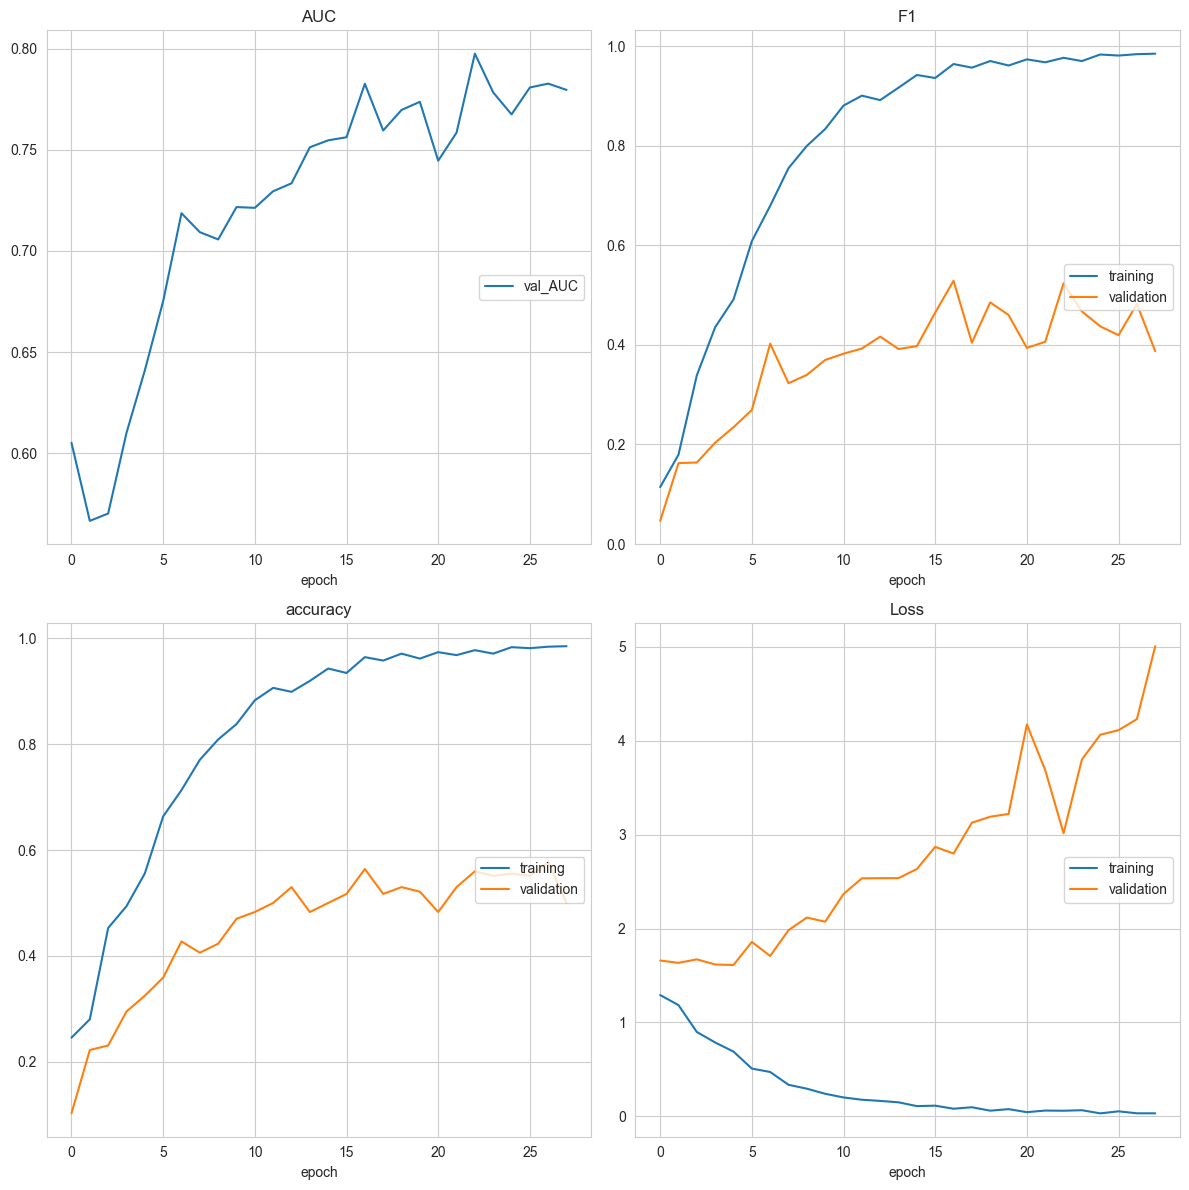

Early stop ep29 | Best val F1: 0.5289 ep17
Done. Best val F1: 0.5289 at ep 17
Elapsed: 226.5 min


In [15]:
EPOCHS = 80

class_counts_list = [class_counts[i] for i in range(num_class)]
total_samples = sum(class_counts_list)
cw = torch.tensor(
    [total_samples / (num_class * c) for c in class_counts_list],
    dtype=torch.float32
).to(device)
print("Class weights:", {class_names[i]: f"{cw[i].item():.2f}" for i in range(num_class)})

loss_function = nn.CrossEntropyLoss(weight=cw)

# LR ligeiramente mais alto — temos 3 blocos e BN frozen para estabilidade
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.features[-3:].named_parameters()
                if p.requires_grad and "bn" not in n],
     "lr": 3e-5, "weight_decay": 1e-4},
    {"params": model.classifier.parameters(),
     "lr": 3e-4, "weight_decay": 1e-3}
])

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=4
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - 4, eta_min=1e-8
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[4]
)

auc_metric = ROCAUCMetric(average="macro")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name, scheduler)
endtime = time.perf_counter()
print(f"Elapsed: {(endtime - starttime)/60:.1f} min")


## Evaluation
Evaluate the model on the test set, compute F1/accuracy and plot a confusion matrix. The following cells perform inference and generate the final metrics and plots.

F1 Score: 0.5543
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [0]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [1]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [1]
Accuracy: 0.633

correct: 4 incorrect: 7
Accuracy: 0.633

correct: 4 incorrect: 7
F1 Score: 0.5543
               precision    recall  f1-score   support

Biliary_Leaks     0.3636    0.2353    0.2857        17
    Lithiasis     0.6312    0.7236    0.6742       123
       Normal     0.5769    0.6977    0.6316        43
    Stricture     0.7302    0.5476    0.6259        84

     accuracy                         0.6330       267
    macro avg     0.5755    0.5510    0.5543       267
 weighted avg     0.6366    0.6330    0.6274       267

[[ 4  7  6  0]
 [ 2 89 15 17]
 [ 1 12 30  0]
 [ 4 33  1 46]]


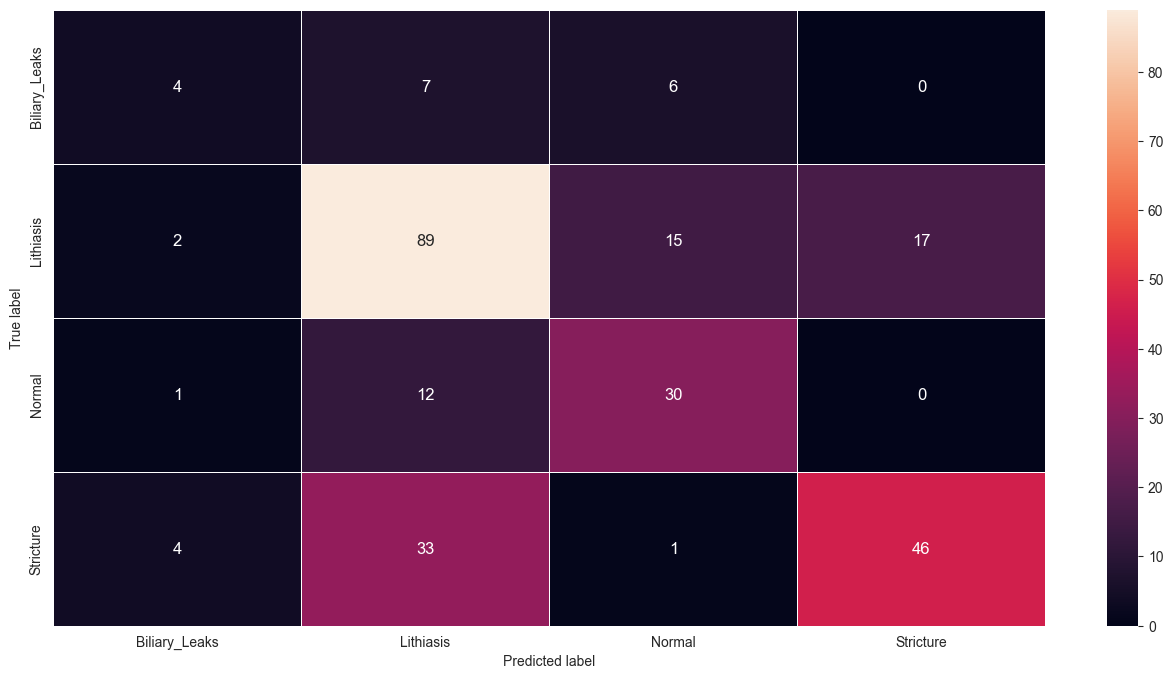

In [16]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    for inputs, labels in test_dl:
        # evaluate the model on the test set
        inputs = inputs.to(device)
        labels = labels.to(device)
        yprev = model(inputs)
        yprev = yprev.detach().cpu().numpy()
        actual = labels.cpu().numpy()
        yprev = np.argmax(yprev, axis=1)
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    
    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')  # Can be 'micro', 'macro' or 'weighted'
    print(f"F1 Score: {f1:0.4f}")
    
    return actual_values, predictions

def display_predictions(actual_values, predictions):
    right = 0
    wrong = 0
    primeiros = 0
    i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        if r == p:
            right += 1
        else:
            wrong += 1
        i += 1
        if i > 10:
            break

    # Compute accuracy
    corrects = np.sum(predictions == actual_values)
    acc = corrects / len(test_loader.dataset)
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score: {f1:0.4f}")

def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()

# Load trained model
model.load_state_dict(torch.load('./' + model_name))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name)

## Test-Time Augmentation (TTA) Evaluation
Average predictions over multiple augmented versions of each test image to boost performance.

Loading best model...
Running TTA on 267 test images...

TTA Results (n=8 passes)
Accuracy : 0.6217
F1 macro : 0.5557

               precision    recall  f1-score   support

Biliary_Leaks     0.4545    0.2941    0.3571        17
    Lithiasis     0.6224    0.7236    0.6692       123
       Normal     0.5385    0.6512    0.5895        43
    Stricture     0.7213    0.5238    0.6069        84

     accuracy                         0.6217       267
    macro avg     0.5842    0.5482    0.5557       267
 weighted avg     0.6293    0.6217    0.6169       267

Confusion matrix:
[[ 5  6  6  0]
 [ 1 89 16 17]
 [ 1 14 28  0]
 [ 4 34  2 44]]


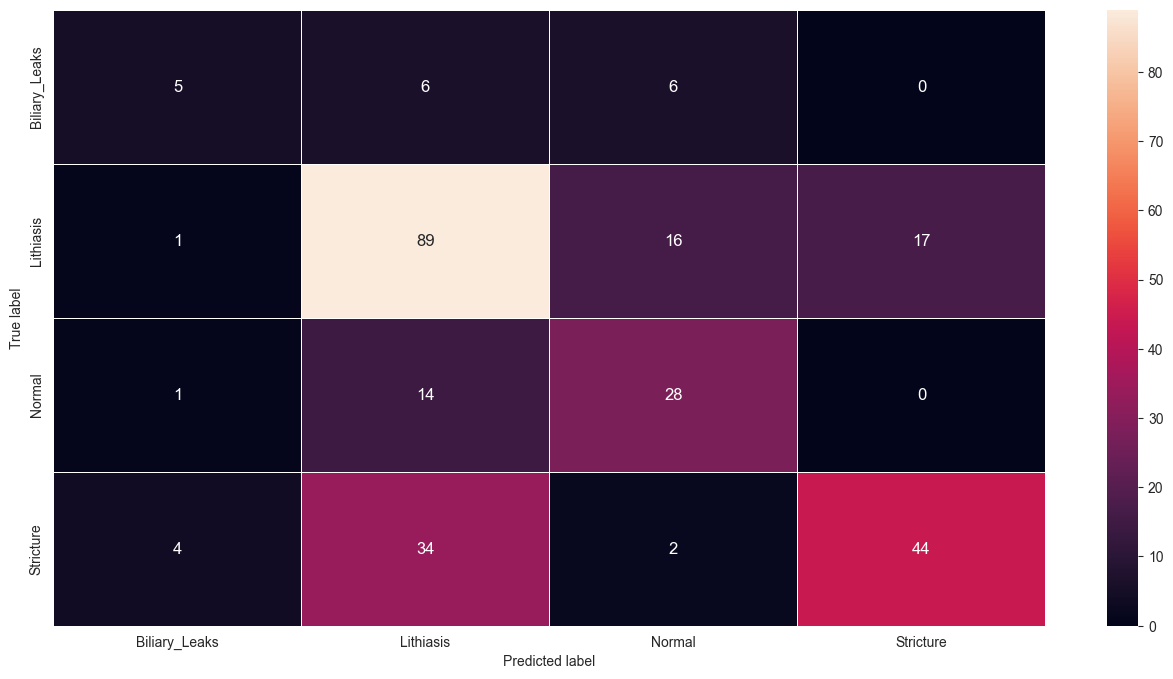

In [17]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def evaluate_with_tta(model, image_paths, labels, n_tta=8):
    """
    Test-Time Augmentation:
    - Cada imagem é avaliada n_tta vezes com augmentation aleatória
    - As probabilidades são médias → argmax final
    """
    tta_aug = Compose([
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        Resize((IMAGE_SIZE, IMAGE_SIZE)),
        RandFlip(spatial_axis=1, prob=0.5),
        RandAdjustContrast(prob=0.5, gamma=(0.85, 1.2)),
        NormalizeIntensity(),
        ToTensor()
    ])

    tta_base = Compose([
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        Resize((IMAGE_SIZE, IMAGE_SIZE)),
        NormalizeIntensity(),
        ToTensor()
    ])

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for path, label in zip(image_paths, labels):
            probs_list = []

            # 1 pass sem augmentation + n_tta-1 com augmentation
            for i in range(n_tta):
                t = tta_base if i == 0 else tta_aug
                try:
                    img = t(path).unsqueeze(0).to(device)
                    out = model(img)
                    prob = torch.softmax(out, dim=1).cpu().numpy()
                    probs_list.append(prob)
                except Exception:
                    continue

            if probs_list:
                avg_prob = np.mean(probs_list, axis=0)
                all_preds.append(np.argmax(avg_prob))
                all_labels.append(label)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)

    print(f"\n{'='*50}")
    print(f"TTA Results (n={n_tta} passes)")
    print(f"{'='*50}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 macro : {f1:.4f}")
    print()
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion matrix:")
    print(cm)
    display_confusion_matrix(cm, class_names, model_name + "_tta")
    return all_labels, all_preds

# ── Load best model and run TTA ───────────────────────────────────────────────
print("Loading best model...")
model.load_state_dict(torch.load(model_name))
model.eval()

print(f"Running TTA on {len(data['test']['images'])} test images...")
tta_labels, tta_preds = evaluate_with_tta(
    model,
    data['test']['images'],
    data['test']['labels'],
    n_tta=8
)


## Grad-CAM — Interpretabilidade (obrigatório)
Visualização das regiões da imagem que mais influenciaram a classificação do modelo.
Gerado para amostras de cada classe do test set.

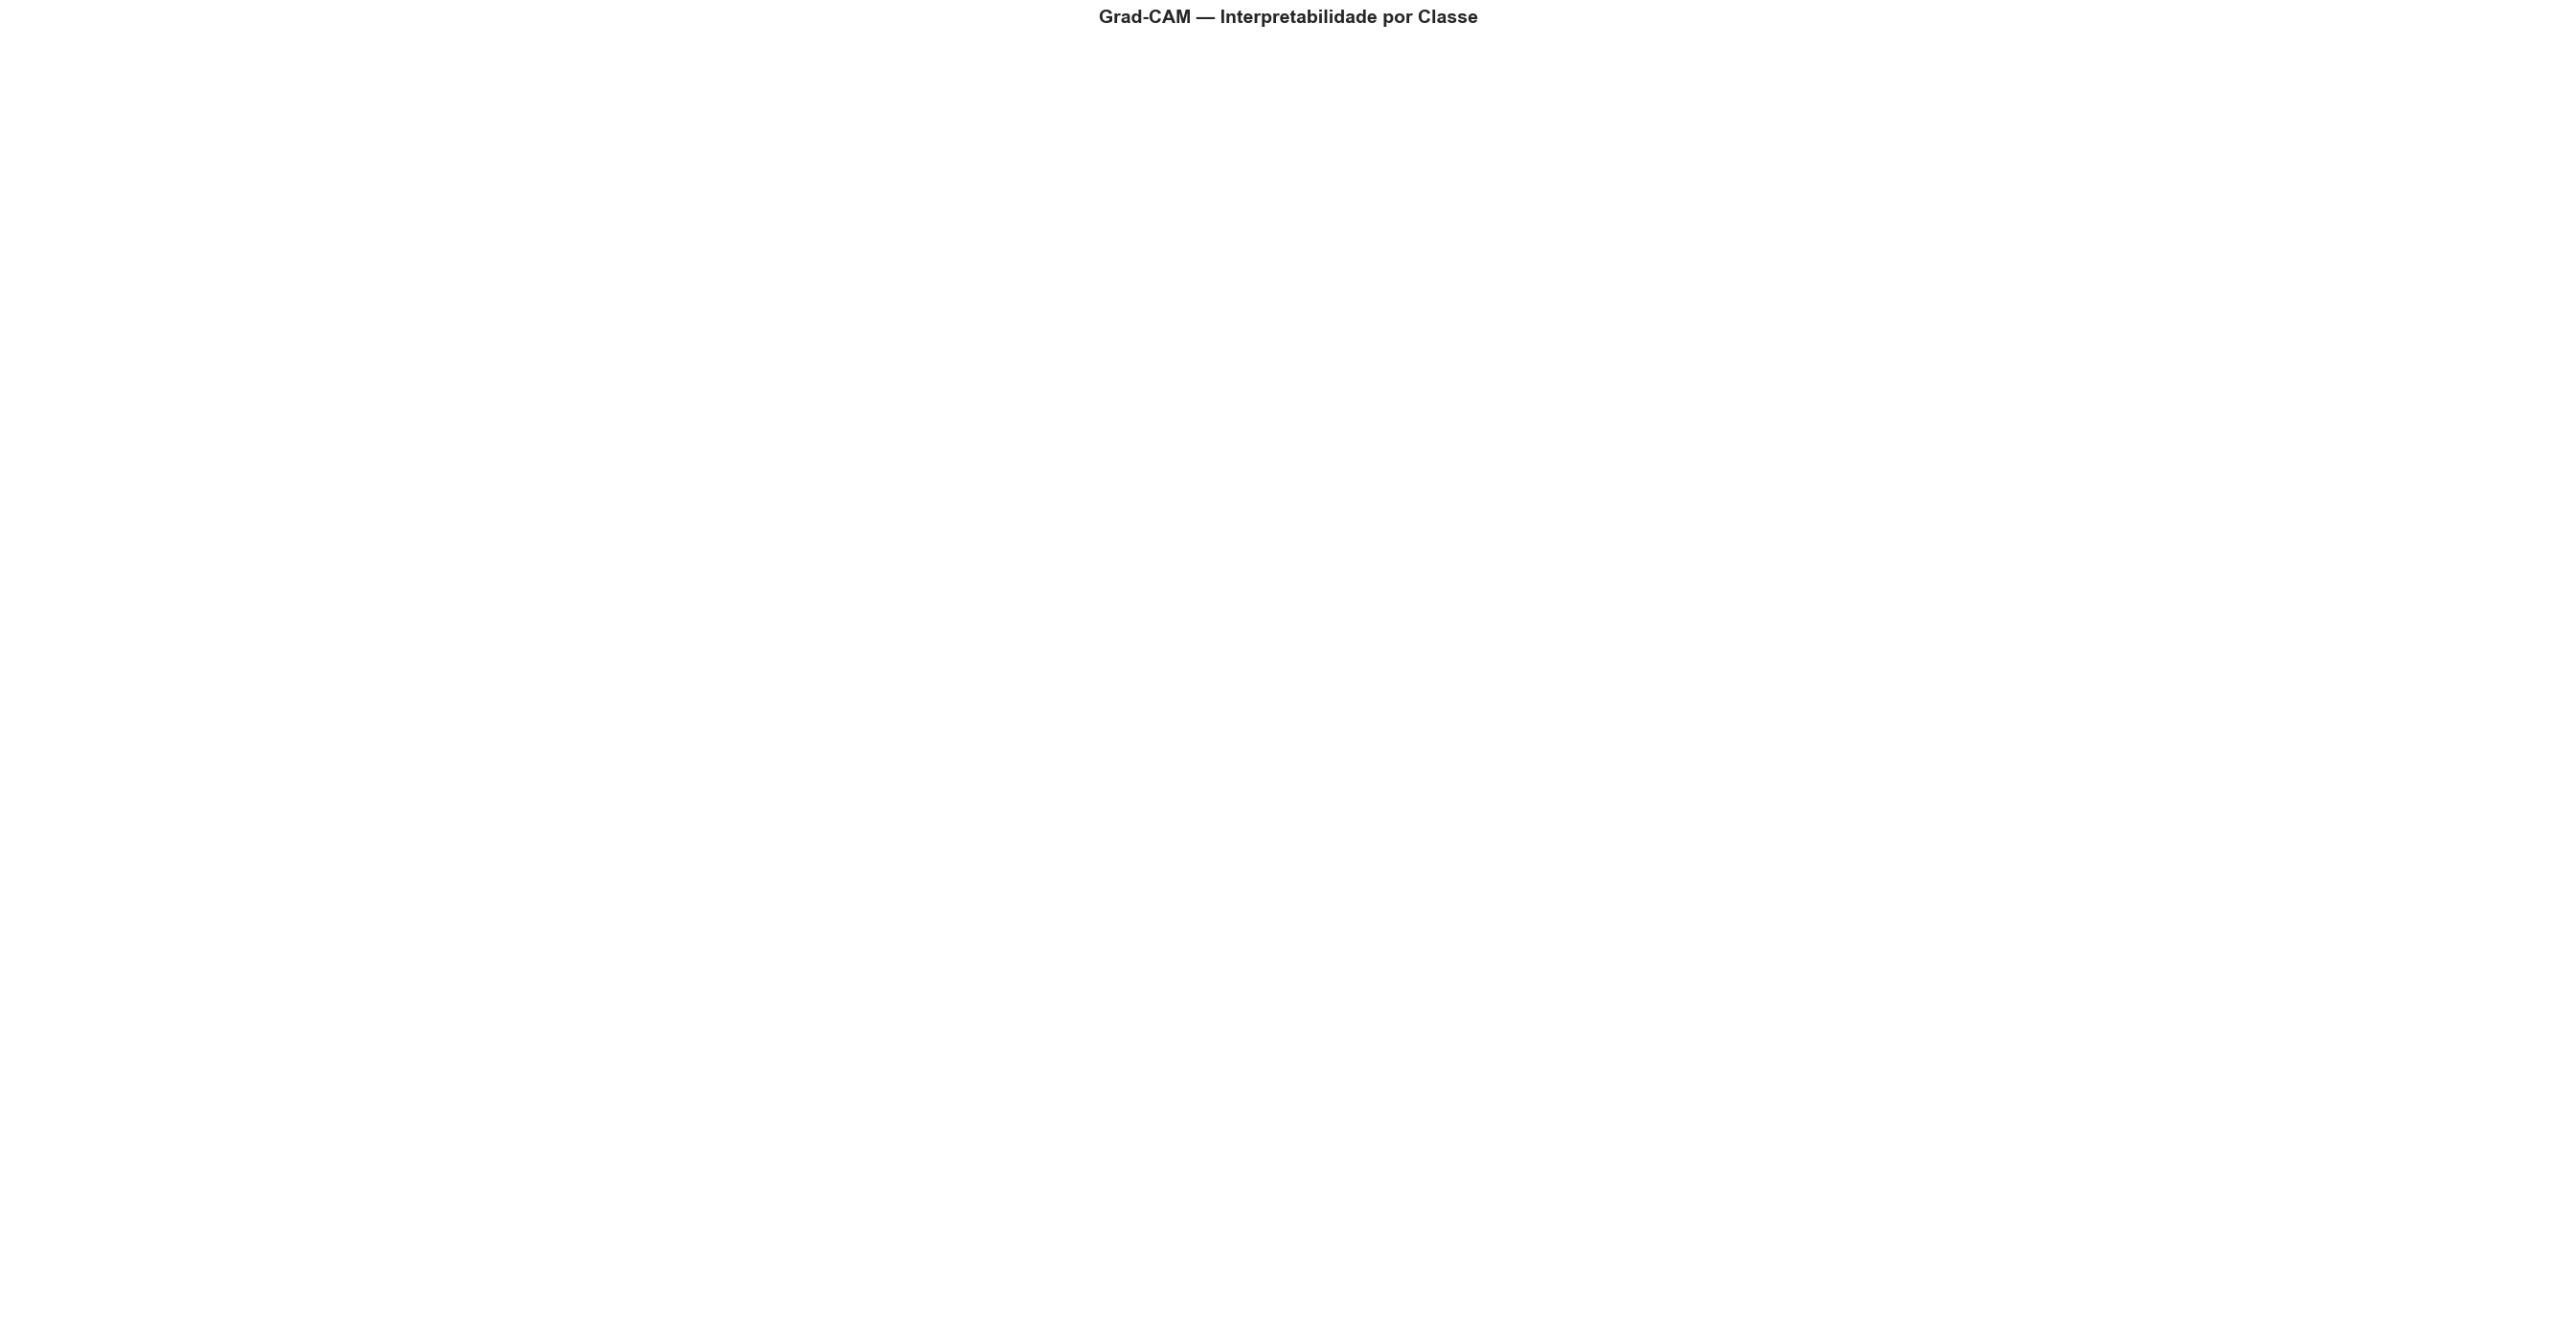

Grad-CAM saved: gradcam_results.png
Verde = previsão correcta | Vermelho = previsão errada


In [18]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from monai.transforms import RandFlip, RandAdjustContrast

# ── Grad-CAM implementation ───────────────────────────────────────────────────
class GradCAM:
    """
    Grad-CAM para EfficientNet-B7.
    Regista activações e gradientes do último bloco convolucional.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        # Global average pooling dos gradientes
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        probs = torch.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, class_idx, probs


def overlay_gradcam(img_tensor, cam, alpha=0.5):
    """Sobrepõe o mapa Grad-CAM na imagem original."""
    img_np = img_tensor.squeeze().cpu().numpy()

    # Handle RGB (3, H, W) → (H, W, 3)
    if img_np.ndim == 3 and img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1, 2, 0))
    elif img_np.ndim == 3 and img_np.shape[0] == 1:
        img_np = img_np[0]

    # Normalise to 0-1
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    # Colormap do CAM
    heatmap = cm.jet(cam)[:, :, :3]

    if img_np.ndim == 2:
        img_rgb = np.stack([img_np] * 3, axis=-1)
    else:
        img_rgb = img_np

    overlay = alpha * heatmap + (1 - alpha) * img_rgb
    overlay = np.clip(overlay, 0, 1)
    return overlay, heatmap


# ── Seleccionar a camada alvo (último bloco do EfficientNet-B7) ───────────────
target_layer = model.features[-1][-1]
gradcam = GradCAM(model, target_layer)

# ── Gerar Grad-CAM para N amostras de cada classe ────────────────────────────
N_PER_CLASS = 3
model.eval()

# Agrupar imagens de teste por classe
from collections import defaultdict
test_by_class = defaultdict(list)
for path, label in zip(data['test']['images'], data['test']['labels']):
    test_by_class[label].append(path)

fig, axes = plt.subplots(
    num_class, N_PER_CLASS * 3,
    figsize=(N_PER_CLASS * 9, num_class * 3.5)
)
fig.suptitle("Grad-CAM — Interpretabilidade por Classe", fontsize=14, fontweight="bold")

for row, cls_idx in enumerate(range(num_class)):
    cls_name  = class_names[cls_idx]
    cls_paths = test_by_class[cls_idx][:N_PER_CLASS]

    for col, img_path in enumerate(cls_paths):
        try:
            img_tensor = val_transforms(img_path).unsqueeze(0).to(device)
            cam, pred_idx, probs = gradcam.generate(img_tensor, class_idx=cls_idx)
            overlay, heatmap = overlay_gradcam(img_tensor, cam)
            pred_name = class_names[pred_idx]
            conf = probs[pred_idx] * 100

            base_col = col * 3
            # Original
            img_show = img_tensor.squeeze().cpu().numpy()
            if img_show.ndim == 3:
                img_show = np.transpose(img_show, (1, 2, 0))
                img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)
            axes[row, base_col].imshow(img_show if img_show.ndim == 3 else img_show, cmap="gray")
            axes[row, base_col].set_title(f"True: {cls_name}", fontsize=8)
            axes[row, base_col].axis("off")

            # Heatmap
            axes[row, base_col+1].imshow(heatmap)
            axes[row, base_col+1].set_title("Grad-CAM", fontsize=8)
            axes[row, base_col+1].axis("off")

            # Overlay
            color = "green" if pred_idx == cls_idx else "red"
            axes[row, base_col+2].imshow(overlay)
            axes[row, base_col+2].set_title(f"Pred: {pred_name}\n({conf:.1f}%)",
                                              fontsize=8, color=color)
            axes[row, base_col+2].axis("off")

        except Exception as e:
            for dc in range(3):
                axes[row, col*3+dc].axis("off")

plt.tight_layout()
plt.savefig("gradcam_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grad-CAM saved: gradcam_results.png")
print("Verde = previsão correcta | Vermelho = previsão errada")


## v11 — 3 blocos + BN frozen + augmentation reforçada

### Diagnóstico v10
- Val F1 ~0.46, AUC ~0.75 — melhor até agora
- Ainda a aprender na epoch 22 quando parou
- Stricture/Lithiasis confusão principal (35 Stricture → Lithiasis)
- Normal muito bom (30/43 = 70%)

### Mudanças v11

| Parâmetro | v10 | v11 | Razão |
|---|---|---|---|
| Blocos descongelados | 2 | **3** | Ainda aprendia na ep 22 |
| BatchNorm | treina | **frozen (eval)** | Batch 16 pequeno → BN instável |
| LR backbone | 2e-5 | **3e-5** | Mais blocos → mais gradiente |
| LR head | 2e-4 | **3e-4** | idem |
| Augmentation | moderada | **reforçada + RandFlip vertical** | Stricture vs Lithiasis |
| Early stopping | 15 | **12** | Equilibrio convergência/degradação |

### Porquê BN frozen?
Com batch=16 e pesos pré-treinados no ImageNet, deixar o BN adaptar-se
introduz ruído nas estatísticas de média/variância. Frozen BN usa as
estatísticas do ImageNet que são mais estáveis e generalizáveis.
